**Imports and Reproducibility Setup**

In [ ]:
import os
import random
from collections import Counter
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler, random_split
from torchvision import models
import torchvision.transforms.functional as TF
import kagglehub
from google.colab import files

SEED = 42

def set_seed(seed: int = SEED):
    """Ensure reproducibility across numpy, random, and torch operations."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[System] Execution device: {device}")

**Cell 2: Kaggle Setup & Authorization**

In [ ]:

!mkdir -p ~/.kaggle
files.upload()
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


**Dataset Fetching and Download paths**

In [ ]:
# Download raw xBD datasets via KaggleHub
train_data_path = kagglehub.dataset_download("nicolaskamanzi/xbd-dataset")
hold_data_path  = kagglehub.dataset_download("nicolaskamanzi/hold-set-xbd-by-xview-2")

# Explicit Directory Definitions
train_root = Path(train_data_path) / "train"
hold_root  = Path(hold_data_path) / "hold"

print(f"[Data] Training Root Directory: {train_root}")
print(f"[Data] Holdout Root Directory:  {hold_root}")

100%|██████████| 7.82G/7.82G [04:17<00:00, 32.6MB/s]

Extracting files...


100%|██████████| 2.61G/2.61G [01:18<00:00, 35.7MB/s]


Extracting files...
[Data] Training Root Directory: /root/.cache/kagglehub/datasets/nicolaskamanzi/xbd-dataset/versions/1/train
[Data] Holdout Root Directory:  /root/.cache/kagglehub/datasets/nicolaskamanzi/hold-set-xbd-by-xview-2/versions/1/hold


**Cell 3: Data Transformations & Custom Dataset Class**

In [ ]:
class PairedTransform:
    """Synchronized spatial transformations applied identically to pre/post disaster image pairs."""
    def __init__(self, size=(224, 224), is_train=True):
        self.size = size
        self.is_train = is_train
        self.mean = [0.485, 0.456, 0.406]
        self.std = [0.229, 0.224, 0.225]

    def __call__(self, img_pre, img_post):
        img_pre = TF.resize(img_pre, self.size)
        img_post = TF.resize(img_post, self.size)

        if self.is_train:
            if random.random() > 0.5:
                img_pre = TF.hflip(img_pre)
                img_post = TF.hflip(img_post)
            if random.random() > 0.5:
                img_pre = TF.vflip(img_pre)
                img_post = TF.vflip(img_post)

        tensor_pre = TF.normalize(TF.to_tensor(img_pre), self.mean, self.std)
        tensor_post = TF.normalize(TF.to_tensor(img_post), self.mean, self.std)

        return tensor_pre, tensor_post


class XBDDataset(Dataset):
    """
    Custom Dataset reader mapping bi-temporal image pairs to target damage masks.
    Remaps 5 original targets down to 4:
      - 0: No Damage (0)
      - 1: Minor Damage (1)
      - 2: Major / Destroyed (Merged 2 & 3)
      - 3: Un-classified (4)
    """
    LABEL_NAMES = [
        "No Damage (0)",
        "Minor (1)",
        "Major/Destroyed (2)",
        "Un-classified (3)"
    ]

    # Target Mapping Dictionary
    LABEL_MAP = {
        0: 0,  # No Damage -> 0
        1: 1,  # Minor -> 1
        2: 2,  # Major -> 2 (Merged)
        3: 2,  # Destroyed -> 2 (Merged)
        4: 3   # Un-classified -> 3
    }

    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.image_dir = self.root_dir / "images"
        self.target_dir = self.root_dir / "targets"
        self.transform = transform

        self.samples = self._index_dataset()
        self.labels = [label for _, _, label in self.samples]

    def _index_dataset(self):
        samples = []
        pre_images = sorted(list(self.image_dir.glob("*_pre_disaster.png")))

        for pre_path in pre_images:
            base_name = pre_path.name.replace("_pre_disaster.png", "")
            post_path = self.image_dir / f"{base_name}_post_disaster.png"
            target_path = self.target_dir / f"{base_name}_post_disaster_target.png"

            if not (post_path.exists() and target_path.exists()):
                continue

            label = self._get_label_from_mask(target_path)
            samples.append((pre_path, post_path, label))

        return samples

    def _get_label_from_mask(self, mask_path):
        """Extracts dominant pixel damage label and maps it into 4 target classes."""
        mask_np = np.array(Image.open(mask_path).convert("L"))
        valid_damage = mask_np[(mask_np > 0) & (mask_np <= 4)]

        if len(valid_damage) == 0:
            raw_label = 0
        else:
            raw_label = int(Counter(valid_damage).most_common(1)[0][0])

        return self.LABEL_MAP[raw_label]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        pre_path, post_path, label = self.samples[idx]

        pre_img = Image.open(pre_path).convert("RGB")
        post_img = Image.open(post_path).convert("RGB")

        if self.transform:
            pre_img, post_img = self.transform(pre_img, post_img)

        return pre_img, post_img, torch.tensor(label, dtype=torch.long)

**Cell 4: DataLoaders Initialization & Class Balancing**

In [ ]:
def create_dataloaders(train_root, hold_root, batch_size=32):
    """Creates train/val/test splits and handles sampling weights for 4 target classes."""
    full_train_dataset = XBDDataset(root_dir=train_root)
    test_dataset = XBDDataset(root_dir=hold_root)

    total_samples = len(full_train_dataset)
    train_len = int(0.85 * total_samples)
    val_len = total_samples - train_len

    train_set, val_set = random_split(
        full_train_dataset,
        [train_len, val_len],
        generator=torch.Generator().manual_seed(SEED)
    )

    train_set.dataset.transform = PairedTransform(is_train=True)
    val_set.dataset.transform = PairedTransform(is_train=False)
    test_dataset.transform = PairedTransform(is_train=False)

    train_labels = [full_train_dataset.labels[i] for i in train_set.indices]
    class_counts = Counter(train_labels)

    print("\n[Audit] Training Set Class Distribution (4-Class Scheme):")
    for cls in sorted(class_counts.keys()):
        print(f"  Class {cls} ({XBDDataset.LABEL_NAMES[cls]}): {class_counts[cls]} samples")

    power = 0.5
    weights_dict = {cls: (1.0 / count) ** power for cls, count in class_counts.items()}
    weight_sum = sum(weights_dict.values())
    weights_dict = {cls: (w / weight_sum) * len(class_counts) for cls, w in weights_dict.items()}

    sample_weights = [weights_dict[lbl] for lbl in train_labels]
    train_sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_set, batch_size=batch_size, sampler=train_sampler, num_workers=2)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    class_weights_tensor = torch.tensor([weights_dict.get(i, 1.0) for i in range(4)], dtype=torch.float).to(device)
    print(f"[Audit] Class Weights Tensor (4 Classes): {class_weights_tensor.cpu().numpy().round(4)}")

    return train_loader, val_loader, test_loader, class_weights_tensor, len(train_set), len(val_set), len(test_dataset)

# Instantiate DataLoaders

train_loader, val_loader, test_loader, class_weights, train_size, val_size, test_size = create_dataloaders(
    train_root, hold_root, batch_size= 32)


[Audit] Training Set Class Distribution (4-Class Scheme):
  Class 0 (No Damage (0)): 489 samples
  Class 1 (Minor (1)): 1163 samples
  Class 2 (Major/Destroyed (2)): 436 samples
  Class 3 (Un-classified (3)): 289 samples
[Audit] Class Weights Tensor (4 Classes): [0.9979 0.6471 1.0569 1.2981]


**Cell 5: Model Architecture Definition**

In [ ]:
class SiameseResNet50(nn.Module):
    """
    Siamese Architecture outputting 4 target class probabilities.
    Combines pre-features, post-features, and absolute feature difference.
    """
    def __init__(self, num_classes: int = 4):
        super(SiameseResNet50, self).__init__()

        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])

        feature_dim = resnet.fc.in_features * 3

        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def extract_features(self, x):
        features = self.backbone(x)
        return torch.flatten(features, 1)

    def forward(self, img_pre, img_post):
        f_pre = self.extract_features(img_pre)
        f_post = self.extract_features(img_post)
        f_diff = torch.abs(f_pre - f_post)

        f_concat = torch.cat((f_pre, f_post, f_diff), dim=1)
        return self.classifier(f_concat)

model = SiameseResNet50(num_classes=4).to(device)
print("[Model] Siamese ResNet-50 (4 Classes) initialized.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 166MB/s]


[Model] Siamese ResNet-50 (4 Classes) initialized.


**Cell 6: Custom Loss Function Definition**

In [ ]:
class FocalLoss(nn.Module):
    """Focal Loss adapted for 4 class targets."""
    def __init__(self, alpha=None, gamma: float = 2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1.0 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

criterion = FocalLoss(alpha=class_weights, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

**Cell 7: Training & Validation Epoch Functions**

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, train_size):
    model.train()
    total_loss = 0.0

    for pre, post, targets in dataloader:
        pre, post, targets = pre.to(device), post.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(pre, post)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * pre.size(0)

    return total_loss / train_size


def validate_epoch(model, dataloader, criterion, device, val_size):
    model.eval()
    total_loss = 0.0
    val_preds, val_targets = [], []

    with torch.no_grad():
        for pre, post, targets in dataloader:
            pre, post, targets = pre.to(device), post.to(device), targets.to(device)

            outputs = model(pre, post)
            loss = criterion(outputs, targets)

            total_loss += loss.item() * pre.size(0)
            preds = torch.argmax(outputs, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(targets.cpu().numpy())

    epoch_loss = total_loss / val_size
    acc = accuracy_score(val_targets, val_preds)
    f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)

    return epoch_loss, acc, f1

**Cell 8: Model Training Loop**

In [ ]:
EPOCHS = 10
best_val_f1 = 0.0
checkpoint_path = "best_siamese_model.pth"
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

print("[Training] Starting 4-class model training...")

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device, train_size)
    val_loss, val_acc, val_f1 = validate_epoch(model, val_loader, criterion, device, val_size)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), checkpoint_path)
        print(f"  --> Checkpoint saved (Best Val F1: {best_val_f1:.4f})")

print("\n[Training] Complete.")

[Training] Starting 4-class model training...
Epoch [01/10] | Train Loss: 0.4070 | Val Loss: 0.2937 | Val Acc: 0.6429 | Val F1: 0.6433
  --> Checkpoint saved (Best Val F1: 0.6433)
Epoch [02/10] | Train Loss: 0.2045 | Val Loss: 0.2708 | Val Acc: 0.6881 | Val F1: 0.6683
  --> Checkpoint saved (Best Val F1: 0.6683)
Epoch [03/10] | Train Loss: 0.1183 | Val Loss: 0.2683 | Val Acc: 0.7214 | Val F1: 0.6952
  --> Checkpoint saved (Best Val F1: 0.6952)
Epoch [04/10] | Train Loss: 0.0666 | Val Loss: 0.2603 | Val Acc: 0.7405 | Val F1: 0.7211
  --> Checkpoint saved (Best Val F1: 0.7211)
Epoch [05/10] | Train Loss: 0.0505 | Val Loss: 0.2627 | Val Acc: 0.7357 | Val F1: 0.7057
Epoch [06/10] | Train Loss: 0.0272 | Val Loss: 0.2708 | Val Acc: 0.7595 | Val F1: 0.7285
  --> Checkpoint saved (Best Val F1: 0.7285)
Epoch [07/10] | Train Loss: 0.0219 | Val Loss: 0.2968 | Val Acc: 0.7667 | Val F1: 0.7325
  --> Checkpoint saved (Best Val F1: 0.7325)
Epoch [08/10] | Train Loss: 0.0147 | Val Loss: 0.2719 | Val A

**Cell 9: Evaluation & Visualization**

[Evaluation] Best checkpoint state loaded.

      FINAL EXTERNAL HOLDOUT EVALUATION REPORT (4 CLASSES)
 Test Loss:     0.3071
 Test Accuracy: 75.03%
 Macro F1:      0.7236

                     precision    recall  f1-score   support

      No Damage (0)       0.80      0.87      0.83       182
          Minor (1)       0.88      0.75      0.81       447
Major/Destroyed (2)       0.64      0.62      0.63       185
  Un-classified (3)       0.52      0.76      0.62       119

           accuracy                           0.75       933
          macro avg       0.71      0.75      0.72       933
       weighted avg       0.77      0.75      0.76       933



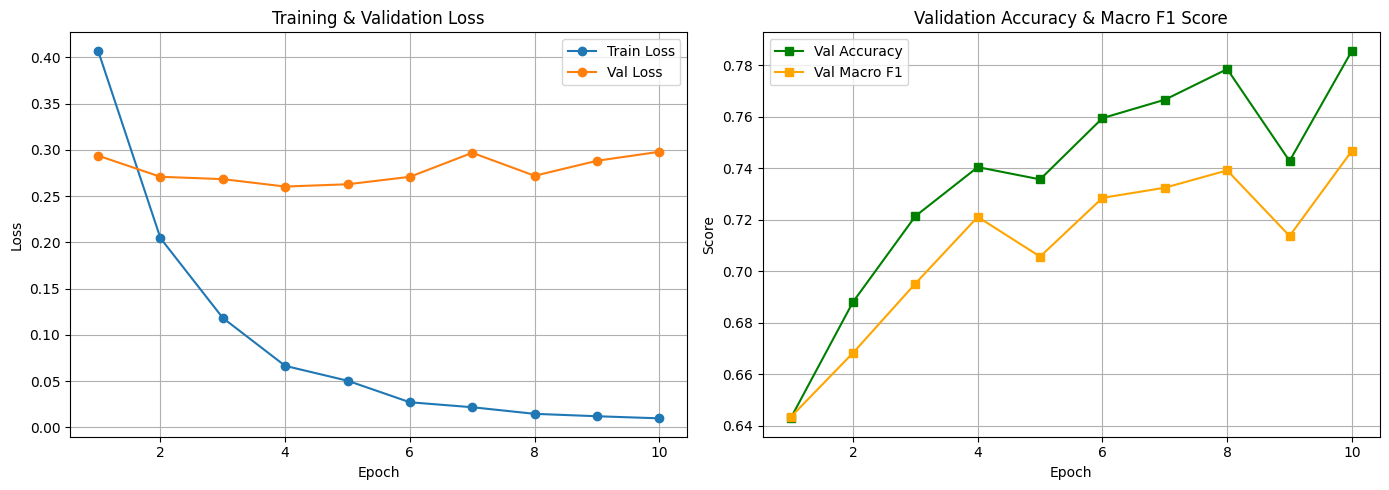

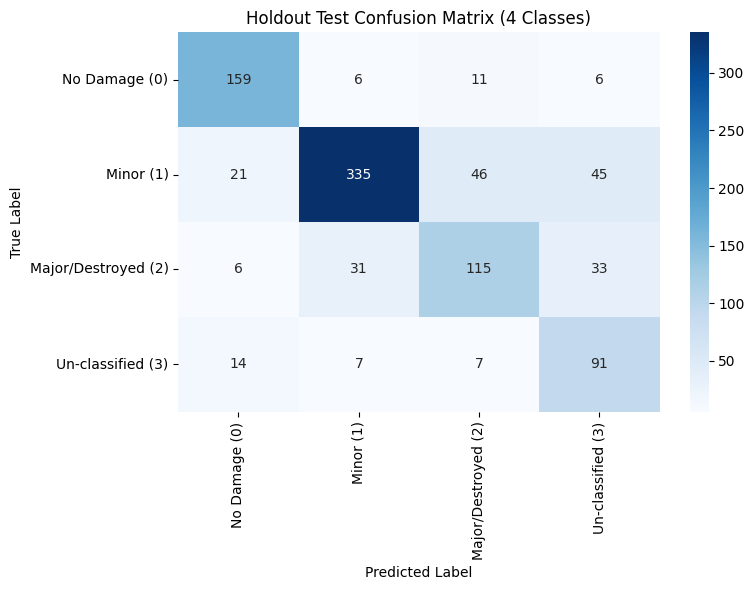

In [ ]:
def evaluate_and_plot(model, test_loader, criterion, device, test_size, history, epochs):
    """Evaluates 4-class model on test set and displays loss curves + confusion matrix."""
    model.eval()
    test_preds, test_targets = [], []
    total_test_loss = 0.0

    with torch.no_grad():
        for pre, post, targets in test_loader:
            pre, post, targets = pre.to(device), post.to(device), targets.to(device)

            outputs = model(pre, post)
            loss = criterion(outputs, targets)

            total_test_loss += loss.item() * pre.size(0)
            preds = torch.argmax(outputs, dim=1)

            test_preds.extend(preds.cpu().numpy())
            test_targets.extend(targets.cpu().numpy())

    test_loss = total_test_loss / test_size
    test_acc = accuracy_score(test_targets, test_preds)
    test_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)

    print("\n" + "=" * 65)
    print("      FINAL EXTERNAL HOLDOUT EVALUATION REPORT (4 CLASSES)")
    print("=" * 65)
    print(f" Test Loss:     {test_loss:.4f}")
    print(f" Test Accuracy: {test_acc * 100:.2f}%")
    print(f" Macro F1:      {test_f1:.4f}")
    print("=" * 65 + "\n")

    print(classification_report(test_targets, test_preds, target_names=XBDDataset.LABEL_NAMES, zero_division=0))

    # Loss and Validation Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(range(1, epochs + 1), history['train_loss'], label="Train Loss", marker='o')
    ax1.plot(range(1, epochs + 1), history['val_loss'], label="Val Loss", marker='o')
    ax1.set_title("Training & Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(range(1, epochs + 1), history['val_acc'], label="Val Accuracy", marker='s', color='green')
    ax2.plot(range(1, epochs + 1), history['val_f1'], label="Val Macro F1", marker='s', color='orange')
    ax2.set_title("Validation Accuracy & Macro F1 Score")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Score")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # Confusion Matrix
    cm = confusion_matrix(test_targets, test_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=XBDDataset.LABEL_NAMES,
                yticklabels=XBDDataset.LABEL_NAMES)
    plt.title("Holdout Test Confusion Matrix (4 Classes)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

# Load best checkpoint weights and run evaluation
if Path(checkpoint_path).exists():
    model.load_state_dict(torch.load(checkpoint_path))
    print("[Evaluation] Best checkpoint state loaded.")

evaluate_and_plot(model, test_loader, criterion, device, test_size, history, EPOCHS)

**Cell 10: Model Export via Joblib**

In [ ]:
save_path = "siamese_resnet50_xbd_4class.joblib"
joblib.dump(model.state_dict(), save_path)
print(f"[Persistence] Saved 4-class model state dictionary to '{save_path}'.")

[Persistence] Saved 4-class model state dictionary to 'siamese_resnet50_xbd_4class.joblib'.
